# Practical Exercise 2 - Task 2
# Vanilla GAN on MNIST with Logistic Loss

In this notebook, we implement a Vanilla GAN on MNIST using logistic loss.

We will:
1. Load the MNIST dataset
2. Build the Generator and Discriminator
3. Replace BCE loss with logistic loss
4. Train the GAN
5. Visualize generated samples

In [1]:
# Standard library imports
import os
import random
from pathlib import Path
from datetime import datetime

# Numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Weights & Biases
import wandb

## General setup

In [2]:
# General experiment setup

LOG_WANDB = True
SEED = 1

# Paths
NOTEBOOK_DIR = Path.cwd()          # e.g. .../src
PROJECT_DIR = NOTEBOOK_DIR.parent  # parent folder of src
WANDB_DIR = PROJECT_DIR
OUT_DIR = PROJECT_DIR / "out"
MODELS_DIR = PROJECT_DIR / "Models"

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Enable cuDNN auto-tuner for fixed-size inputs
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# Data loading settings
PIN_MEMORY = True if torch.cuda.is_available() else False
NUM_WORKERS = 8

# CPU optimization
torch.set_num_threads(8)
torch.set_num_interop_threads(8)

Using device: cuda


## Configuration

In [3]:
# Training configuration
config = {
    "batch_size": 128,
    "latent_dim": 100,
    "g_hidden_dim": 128,
    "d_hidden_dim": 128,
    "image_dim": 28 * 28,
    "g_lr": 1e-3,
    "d_lr": 1e-3,
    "epochs": 100,
    "jupyter_plot_interval": 10,
    "wandb_image_interval": 1,
    "optimizer": "Adam",
    "betas": (0.9, 0.999),
    "dataset": "MNIST",
    "model": "Vanilla GAN - Logistic Loss",
    "seed": SEED,
    "loss_type": "logistic_loss"
}

config

{'batch_size': 128,
 'latent_dim': 100,
 'g_hidden_dim': 128,
 'd_hidden_dim': 128,
 'image_dim': 784,
 'g_lr': 0.001,
 'd_lr': 0.001,
 'epochs': 100,
 'jupyter_plot_interval': 10,
 'wandb_image_interval': 1,
 'optimizer': 'Adam',
 'betas': (0.9, 0.999),
 'dataset': 'MNIST',
 'model': 'Vanilla GAN - Logistic Loss',
 'seed': 1,
 'loss_type': 'logistic_loss'}

## Helper function for readable checkpoint names

In [4]:
# Build a readable file name for checkpoints
def build_model_name(config, task_name="task2", file_ext="pt"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    return (
        f"{task_name}"
        f"_ep{config['epochs']}"
        f"_bs{config['batch_size']}"
        f"_glr{config['g_lr']}"
        f"_dlr{config['d_lr']}"
        f"_gh{config['g_hidden_dim']}"
        f"_dh{config['d_hidden_dim']}"
        f"_seed{config['seed']}"
        f"_{timestamp}.{file_ext}"
    )

## Initialize Weights & Biases

In [5]:
# Shared W&B settings
WANDB_ENTITY = "d7047e-group12"
WANDB_PROJECT = "Lab2"

wandb_kwargs = dict(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="Task2 - Vanilla GAN Logistic Loss",
    tags=["Task 2", "GAN", "MNIST", "Logistic Loss"],
    dir=str(WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

wandb.login()
wandb.init(**wandb_kwargs)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Load MNIST dataset

In [6]:
# Transform pipeline for MNIST
# ToTensor converts images to tensors in the range [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the training set
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# DataLoader handles batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 468


## Visualize a few real images

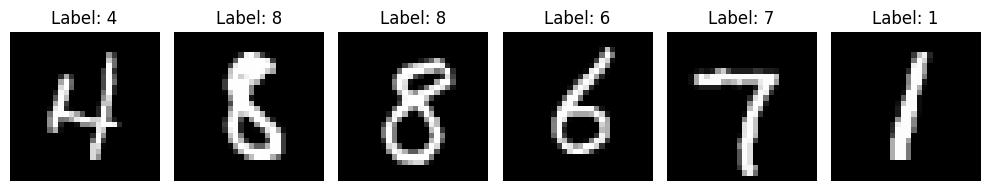

In [7]:
# Get one batch of real images
real_images, real_labels = next(iter(train_loader))

# Plot a few images from the batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Define the Generator network

In [8]:
# Generator network
# Input: latent noise vector
# Output: generated image vector of size 784

class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, image_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, image_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.model(z)

## Define the Discriminator network

In [9]:
# Discriminator network
# Input: flattened image vector
# Output: raw score (logit), not probability

class Discriminator(nn.Module):
    def __init__(self, image_dim, hidden_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(image_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.model(x)

## Initialize models

In [10]:
# Create model instances and move them to device
G = Generator(
    latent_dim=config["latent_dim"],
    hidden_dim=config["g_hidden_dim"],
    image_dim=config["image_dim"]
).to(device)

D = Discriminator(
    image_dim=config["image_dim"],
    hidden_dim=config["d_hidden_dim"]
).to(device)

print(G)
print()
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


## Define logistic loss and optimizers

In [11]:
# Logistic loss helper functions
# softplus(x) = log(1 + exp(x))

def discriminator_logistic_loss(real_logits, fake_logits):
    real_loss = F.softplus(-real_logits).mean()
    fake_loss = F.softplus(fake_logits).mean()
    total_loss = real_loss + fake_loss
    return total_loss, real_loss, fake_loss

def generator_logistic_loss(fake_logits):
    return F.softplus(-fake_logits).mean()

# Separate optimizers for Generator and Discriminator
g_optimizer = optim.Adam(
    G.parameters(),
    lr=config["g_lr"],
    betas=config["betas"]
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=config["d_lr"],
    betas=config["betas"]
)

## Helper function to visualize generated images

In [12]:
# Display generated images inside the notebook
def show_generated_images(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    generator.train()

## Helper function for W&B image logging

In [13]:
# Create a matplotlib figure for W&B image logging
def make_generated_figure(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    generator.train()
    return fig

## Helper function for saving final model

In [14]:
# Helper function to build a readable checkpoint name
from datetime import datetime

def build_model_name(config, task_name="task1", file_ext="pt"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    model_name = (
        f"{task_name}"
        f"_model-{config['model'].replace(' ', '_')}"
        f"_data-{config['dataset']}"
        f"_ep-{config['epochs']}"
        f"_bs-{config['batch_size']}"
        f"_glr-{config['g_lr']}"
        f"_dlr-{config['d_lr']}"
        f"_gh-{config['g_hidden_dim']}"
        f"_dh-{config['d_hidden_dim']}"
        f"_seed-{config['seed']}"
        f"_{timestamp}.{file_ext}"
    )

    return model_name

## Save checkpoints at selected epochs

In [15]:
def save_generated_grid(generator, latent_dim, save_path, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.close(fig)

    generator.train()

## Train the Vanilla GAN with logistic loss

Epoch [1/100] | D_loss: 0.2074 | G_loss: 4.2983
Epoch [2/100] | D_loss: 0.0563 | G_loss: 6.6499
Epoch [3/100] | D_loss: 0.0850 | G_loss: 5.1514
Epoch [4/100] | D_loss: 0.0892 | G_loss: 4.6503
Epoch [5/100] | D_loss: 0.0872 | G_loss: 4.7395
Saved generated samples to: /root/D7047E/Lab2/out/task2_logistic_epoch_5.png
Epoch [6/100] | D_loss: 0.0770 | G_loss: 5.6189
Epoch [7/100] | D_loss: 0.1073 | G_loss: 5.6868
Epoch [8/100] | D_loss: 0.1634 | G_loss: 5.3027
Epoch [9/100] | D_loss: 0.2292 | G_loss: 5.4484
Epoch [10/100] | D_loss: 0.2609 | G_loss: 4.8257


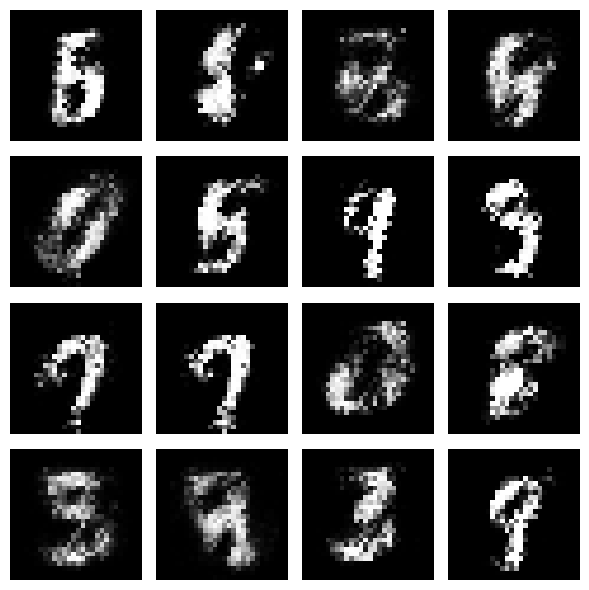

Saved generated samples to: /root/D7047E/Lab2/out/task2_logistic_epoch_10.png
Epoch [11/100] | D_loss: 0.3544 | G_loss: 4.5064
Epoch [12/100] | D_loss: 0.4260 | G_loss: 4.1143
Epoch [13/100] | D_loss: 0.5205 | G_loss: 4.0531
Epoch [14/100] | D_loss: 0.6224 | G_loss: 3.5585
Epoch [15/100] | D_loss: 0.5996 | G_loss: 3.5347
Epoch [16/100] | D_loss: 0.6199 | G_loss: 3.7280
Epoch [17/100] | D_loss: 0.6754 | G_loss: 3.3361
Epoch [18/100] | D_loss: 0.7669 | G_loss: 3.1703
Epoch [19/100] | D_loss: 0.7937 | G_loss: 2.9792
Epoch [20/100] | D_loss: 0.7803 | G_loss: 2.8432


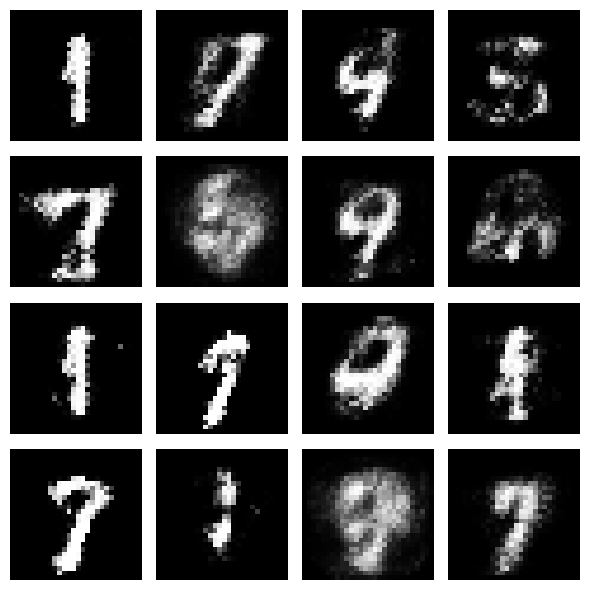

Epoch [21/100] | D_loss: 0.8309 | G_loss: 2.7207
Epoch [22/100] | D_loss: 0.8186 | G_loss: 2.7351
Epoch [23/100] | D_loss: 0.8249 | G_loss: 2.7620
Epoch [24/100] | D_loss: 0.7892 | G_loss: 2.6849
Epoch [25/100] | D_loss: 0.8112 | G_loss: 2.5844
Epoch [26/100] | D_loss: 0.8179 | G_loss: 2.5067
Epoch [27/100] | D_loss: 0.8352 | G_loss: 2.6323
Epoch [28/100] | D_loss: 0.8494 | G_loss: 2.4247
Epoch [29/100] | D_loss: 0.7988 | G_loss: 2.3987
Epoch [30/100] | D_loss: 0.8038 | G_loss: 2.3523


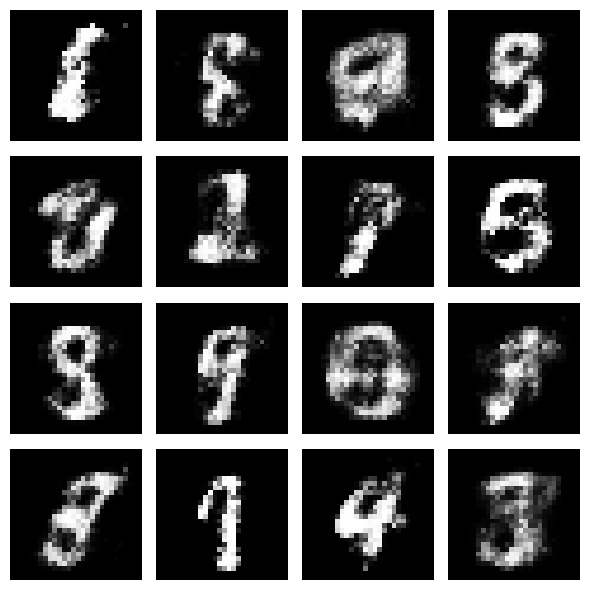

Epoch [31/100] | D_loss: 0.7885 | G_loss: 2.3353
Epoch [32/100] | D_loss: 0.7812 | G_loss: 2.3647
Epoch [33/100] | D_loss: 0.8099 | G_loss: 2.2928
Epoch [34/100] | D_loss: 0.8282 | G_loss: 2.2412
Epoch [35/100] | D_loss: 0.8596 | G_loss: 2.1508
Epoch [36/100] | D_loss: 0.8259 | G_loss: 2.1641
Epoch [37/100] | D_loss: 0.8355 | G_loss: 2.1226
Epoch [38/100] | D_loss: 0.8109 | G_loss: 2.1512
Epoch [39/100] | D_loss: 0.8054 | G_loss: 2.1195
Epoch [40/100] | D_loss: 0.7902 | G_loss: 2.1587


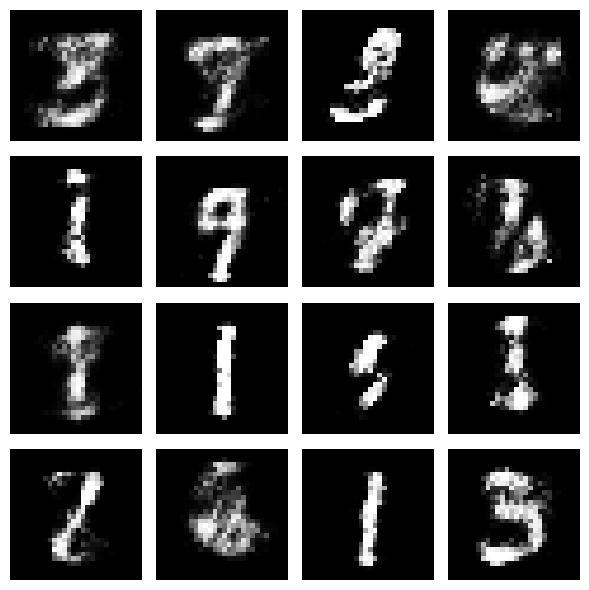

Epoch [41/100] | D_loss: 0.7968 | G_loss: 2.1562
Epoch [42/100] | D_loss: 0.8220 | G_loss: 2.0772
Epoch [43/100] | D_loss: 0.8385 | G_loss: 2.0383
Epoch [44/100] | D_loss: 0.8283 | G_loss: 2.0663
Epoch [45/100] | D_loss: 0.8299 | G_loss: 2.0914
Epoch [46/100] | D_loss: 0.8291 | G_loss: 2.0789
Epoch [47/100] | D_loss: 0.8409 | G_loss: 2.0310
Epoch [48/100] | D_loss: 0.8419 | G_loss: 1.9953
Epoch [49/100] | D_loss: 0.8278 | G_loss: 1.9939
Epoch [50/100] | D_loss: 0.8336 | G_loss: 1.9992


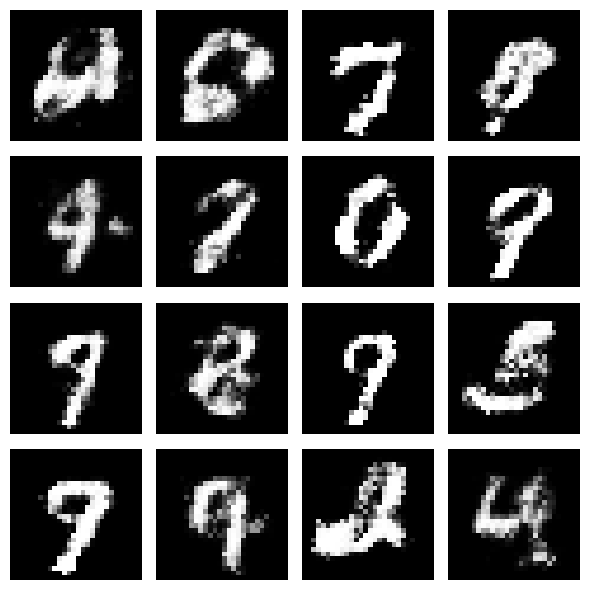

Saved generated samples to: /root/D7047E/Lab2/out/task2_logistic_epoch_50.png
Epoch [51/100] | D_loss: 0.8563 | G_loss: 1.9766
Epoch [52/100] | D_loss: 0.8469 | G_loss: 1.9567
Epoch [53/100] | D_loss: 0.8212 | G_loss: 2.0016
Epoch [54/100] | D_loss: 0.8294 | G_loss: 2.0036
Epoch [55/100] | D_loss: 0.8094 | G_loss: 2.0350
Epoch [56/100] | D_loss: 0.8239 | G_loss: 1.9784
Epoch [57/100] | D_loss: 0.8142 | G_loss: 1.9591
Epoch [58/100] | D_loss: 0.8070 | G_loss: 1.9834
Epoch [59/100] | D_loss: 0.7978 | G_loss: 1.9686
Epoch [60/100] | D_loss: 0.8069 | G_loss: 1.9820


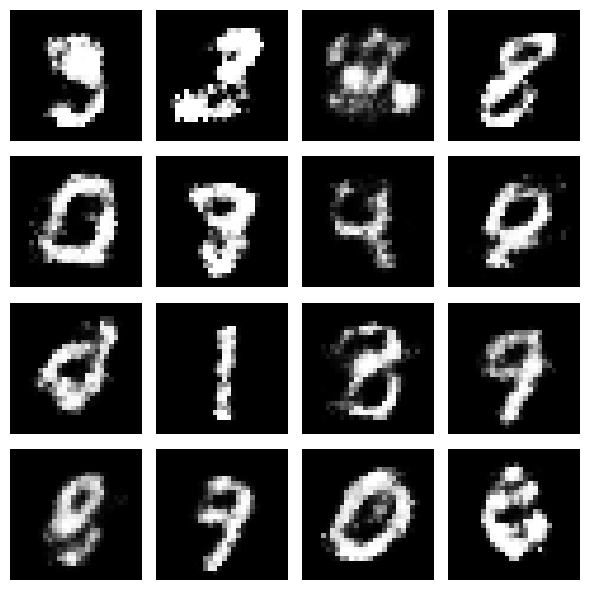

Epoch [61/100] | D_loss: 0.7938 | G_loss: 1.9960
Epoch [62/100] | D_loss: 0.7867 | G_loss: 2.0495
Epoch [63/100] | D_loss: 0.7882 | G_loss: 2.0941
Epoch [64/100] | D_loss: 0.7926 | G_loss: 2.0775
Epoch [65/100] | D_loss: 0.7803 | G_loss: 2.0664
Epoch [66/100] | D_loss: 0.7669 | G_loss: 2.1714
Epoch [67/100] | D_loss: 0.7796 | G_loss: 2.1040
Epoch [68/100] | D_loss: 0.7864 | G_loss: 2.0373
Epoch [69/100] | D_loss: 0.7879 | G_loss: 2.0387
Epoch [70/100] | D_loss: 0.7899 | G_loss: 2.0194


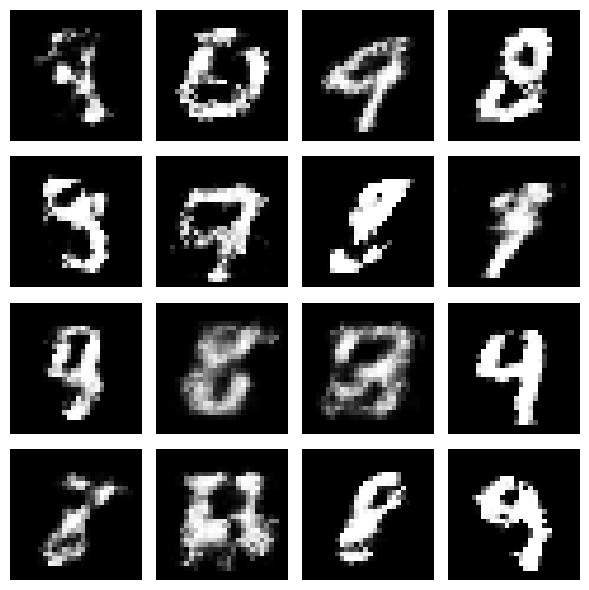

Epoch [71/100] | D_loss: 0.7941 | G_loss: 2.0085
Epoch [72/100] | D_loss: 0.7931 | G_loss: 2.0705
Epoch [73/100] | D_loss: 0.7895 | G_loss: 2.1121
Epoch [74/100] | D_loss: 0.7947 | G_loss: 2.0605
Epoch [75/100] | D_loss: 0.8013 | G_loss: 2.0172
Epoch [76/100] | D_loss: 0.8137 | G_loss: 1.9640
Epoch [77/100] | D_loss: 0.8105 | G_loss: 1.9998
Epoch [78/100] | D_loss: 0.7981 | G_loss: 2.0246
Epoch [79/100] | D_loss: 0.8128 | G_loss: 1.9621
Epoch [80/100] | D_loss: 0.8073 | G_loss: 1.9634


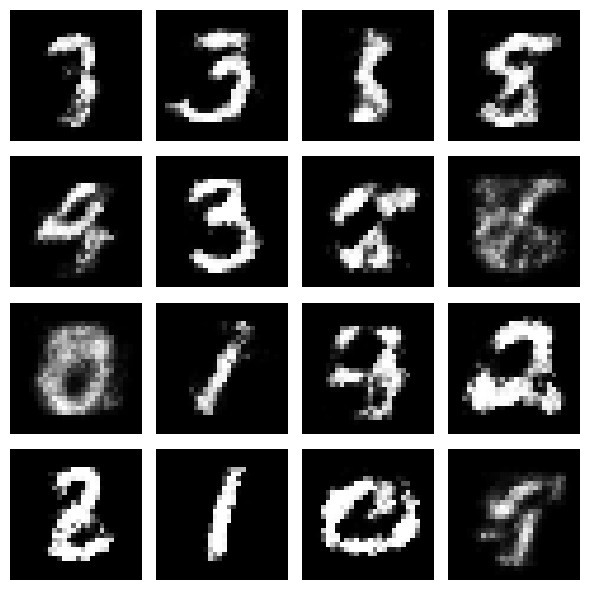

Epoch [81/100] | D_loss: 0.8177 | G_loss: 1.9773
Epoch [82/100] | D_loss: 0.8117 | G_loss: 1.9611
Epoch [83/100] | D_loss: 0.8207 | G_loss: 1.9641
Epoch [84/100] | D_loss: 0.8117 | G_loss: 1.9873
Epoch [85/100] | D_loss: 0.8259 | G_loss: 1.9432
Epoch [86/100] | D_loss: 0.8258 | G_loss: 1.9120
Epoch [87/100] | D_loss: 0.8311 | G_loss: 1.9236
Epoch [88/100] | D_loss: 0.8204 | G_loss: 1.9569
Epoch [89/100] | D_loss: 0.8248 | G_loss: 1.8929
Epoch [90/100] | D_loss: 0.8401 | G_loss: 1.8676


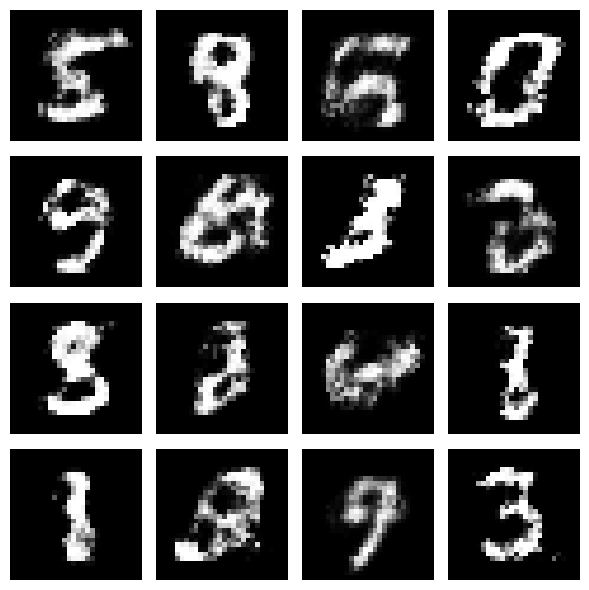

Epoch [91/100] | D_loss: 0.8390 | G_loss: 1.8733
Epoch [92/100] | D_loss: 0.8325 | G_loss: 1.8796
Epoch [93/100] | D_loss: 0.8296 | G_loss: 1.8802
Epoch [94/100] | D_loss: 0.8398 | G_loss: 1.9052
Epoch [95/100] | D_loss: 0.8426 | G_loss: 1.8625
Epoch [96/100] | D_loss: 0.8352 | G_loss: 1.8815
Epoch [97/100] | D_loss: 0.8377 | G_loss: 1.8818
Epoch [98/100] | D_loss: 0.8393 | G_loss: 1.8685
Epoch [99/100] | D_loss: 0.8419 | G_loss: 1.8505
Epoch [100/100] | D_loss: 0.8441 | G_loss: 1.8231


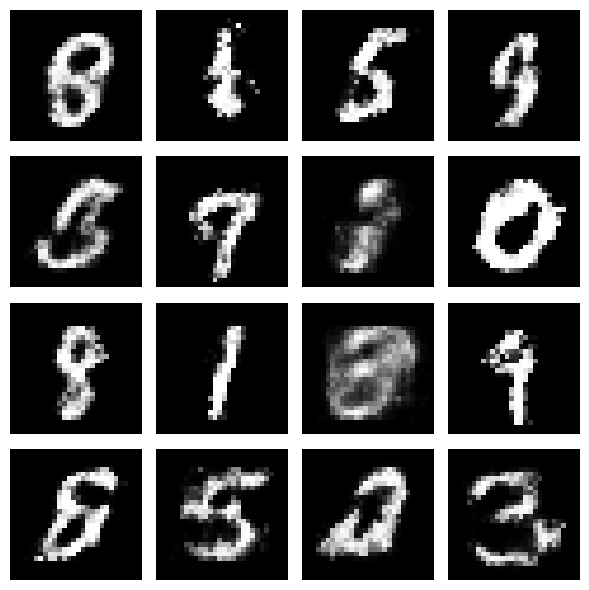

Saved generated samples to: /root/D7047E/Lab2/out/task2_logistic_epoch_100.png


In [16]:
# Main training loop with epoch-level logging
# Also save generated samples at epochs 5, 10, 50, and 100

save_epochs = {5, 10, 50, 100}

for epoch in range(config["epochs"]):
    d_loss_list = []
    g_loss_list = []
    d_real_loss_list = []
    d_fake_loss_list = []

    for batch_idx, (real_images, _) in enumerate(train_loader):
        real_images = real_images.view(-1, config["image_dim"]).to(device, non_blocking=True)
        batch_size = real_images.size(0)

        # 1) Train Discriminator
        z = torch.randn(batch_size, config["latent_dim"], device=device)
        fake_images = G(z)

        real_logits = D(real_images)
        fake_logits = D(fake_images.detach())

        d_loss, d_real_loss, d_fake_loss = discriminator_logistic_loss(real_logits, fake_logits)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # 2) Train Generator
        z = torch.randn(batch_size, config["latent_dim"], device=device)
        fake_images = G(z)

        fake_logits_for_g = D(fake_images)
        g_loss = generator_logistic_loss(fake_logits_for_g)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        d_loss_list.append(d_loss.item())
        g_loss_list.append(g_loss.item())
        d_real_loss_list.append(d_real_loss.item())
        d_fake_loss_list.append(d_fake_loss.item())

    avg_d_loss = np.mean(d_loss_list)
    avg_g_loss = np.mean(g_loss_list)
    avg_d_real_loss = np.mean(d_real_loss_list)
    avg_d_fake_loss = np.mean(d_fake_loss_list)

    print(
        f"Epoch [{epoch + 1}/{config['epochs']}] | "
        f"D_loss: {avg_d_loss:.4f} | "
        f"G_loss: {avg_g_loss:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "D_loss": avg_d_loss,
        "G_loss": avg_g_loss,
        "D_real_loss": avg_d_real_loss,
        "D_fake_loss": avg_d_fake_loss
    }, step=epoch + 1)

    if (epoch + 1) % config["wandb_image_interval"] == 0:
        fig = make_generated_figure(G, config["latent_dim"], num_images=16)

        wandb.log({
            "generated_samples": wandb.Image(fig, caption=f"Epoch {epoch + 1}")
        }, step=epoch + 1)

        if (epoch + 1) % config["jupyter_plot_interval"] == 0:
            plt.show()

        plt.close(fig)

    if (epoch + 1) in save_epochs:
        save_path = OUT_DIR / f"task2_logistic_epoch_{epoch + 1}.png"
        save_generated_grid(
            generator=G,
            latent_dim=config["latent_dim"],
            save_path=save_path,
            num_images=16
        )
        print(f"Saved generated samples to: {save_path}")

## Display final generated samples

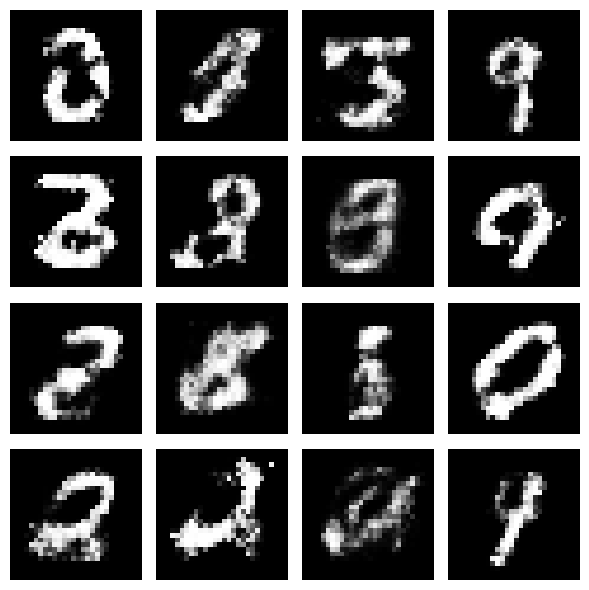

In [17]:
# Show final generated images after training
show_generated_images(G, config["latent_dim"], num_images=16)

## Save trained models

In [18]:
# Save a full training checkpoint
checkpoint_name = build_model_name(config, task_name="task2_logistic")
checkpoint_path = MODELS_DIR / checkpoint_name

torch.save({
    "task": "Task 2",
    "model_type": config["model"],
    "dataset": config["dataset"],
    "epoch": config["epochs"],
    "generator_state_dict": G.state_dict(),
    "discriminator_state_dict": D.state_dict(),
    "g_optimizer_state_dict": g_optimizer.state_dict(),
    "d_optimizer_state_dict": d_optimizer.state_dict(),
    "config": config,
    "device_used": str(device),
}, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")

Checkpoint saved to: /root/D7047E/Lab2/Models/task2_logistic_model-Vanilla_GAN_-_Logistic_Loss_data-MNIST_ep-100_bs-128_glr-0.001_dlr-0.001_gh-128_dh-128_seed-1_20260419_144949.pt


In [19]:
# Save Generator weights only
generator_name = build_model_name(config, task_name="task2_logistic_generator")
generator_path = MODELS_DIR / generator_name

torch.save(G.state_dict(), generator_path)

print(f"Generator weights saved to: {generator_path}")

Generator weights saved to: /root/D7047E/Lab2/Models/task2_logistic_generator_model-Vanilla_GAN_-_Logistic_Loss_data-MNIST_ep-100_bs-128_glr-0.001_dlr-0.001_gh-128_dh-128_seed-1_20260419_144949.pt


## Finish the W&B run

In [20]:
wandb.finish()

D_fake_loss,▁▂▂▄▅▇▇▇▇█▇▇█▇████████████▇▇▇███████████
D_loss,▁▂▃▃▅▆▆██▇██▇▇██████▇█▇▇▇▇▇▇▇▇██████████
D_real_loss,▁▁▁▂▃▅▆▆▇█████▇██▇███▇▇▇▇▇▇▇▇▇▇▇█▇██████
G_loss,█▆▅▆▇▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█
D_fake_loss,0.3981
D_loss,0.84408
D_real_loss,0.44598
G_loss,1.8231
epoch,100
